# Chest X-Ray Görüntülerinin CNN ile Sınıflandırılması

**Öğrenci:** MAHMOUD KARZOUN  
**No:** 251238003  
**Bölüm:** Bilgisayar Programcılığı  
**Üniversite:** KTO Karatay Üniversitesi  

**Veri Kümesi:** Chest X-Ray Images (Pneumonia)  
**Kaggle Link:**  
https://www.kaggle.com/datasets/paultimothymooney/chest-xray-pneumonia


## İçindekiler (Proje Adımları)

1. Veri Seti Bulma (Kaggle)  
2. Veri Analizi  
   - Görüntü sayısı  
   - Sınıf sayısı  
   - Rastgele örnek görseller  
3. Kod Yazarak (Genel Hazırlık)  
4. Eğitim ve Test Setlerinin Hazırlanması  
5. CNN Modeli Oluşturma  
6. Modeli Eğitme (Epoch)  
7. Model Test Etme  
8. Grafiklerin Oluşturulması  
   - Accuracy  
   - Loss  
9. Confusion Matrix  
10. Raporlama


In [2]:
!pip -q install kagglehub

In [3]:
import kagglehub
path = kagglehub.dataset_download(
    "paultimothymooney/chest-xray-pneumonia"
)

print("Dataset path:", path)

Using Colab cache for faster access to the 'chest-xray-pneumonia' dataset.
Dataset path: /kaggle/input/chest-xray-pneumonia


In [4]:
import os
from pathlib import Path

# chest_xray لاقي ملفو
candidate = Path(path) / "chest_xray"

if candidate.exists():
    base_dir = candidate
else:
    # اذا في كمان ملفات ابحثها
    for root, dirs, files in os.walk(path):
        if "chest_xray" in dirs:
            base_dir = Path(root) / "chest_xray"
            break

print("Base dir:", base_dir)
print("Alt klasörler:", os.listdir(base_dir))

Base dir: /kaggle/input/chest-xray-pneumonia/chest_xray
Alt klasörler: ['chest_xray', '__MACOSX', 'val', 'test', 'train']


In [5]:
# ملفات الي رح يتعلم منن
train_normal = base_dir / "train" / "NORMAL"
train_pneu   = base_dir / "train" / "PNEUMONIA"

# عد الصور الي تطلع
def count_images(folder):
    return len([f for f in folder.iterdir() if f.suffix.lower() in [".jpg", ".jpeg", ".png"]])

print("NORMAL:", count_images(train_normal))
print("PNEUMONIA:", count_images(train_pneu))

NORMAL: 1341
PNEUMONIA: 3875


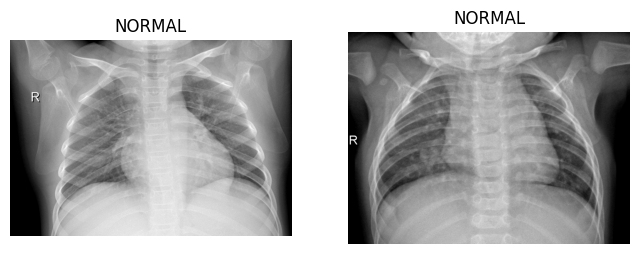

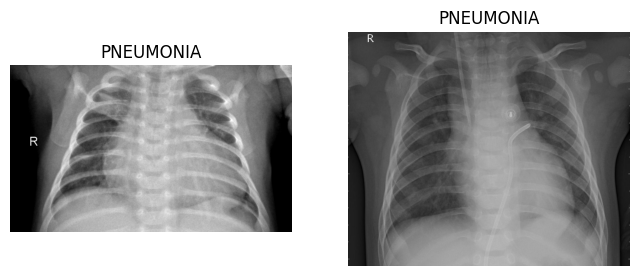

In [6]:
import random
import matplotlib.pyplot as plt
from PIL import Image

def show_random(folder, title, n=2):
    files = list(folder.iterdir())
    picks = random.sample(files, n)

    plt.figure(figsize=(8,4))
    for i, img_path in enumerate(picks, 1):
        img = Image.open(img_path).convert("RGB")
        plt.subplot(1, n, i)
        plt.imshow(img)
        plt.axis("off")
        plt.title(title)
    plt.show()

show_random(train_normal, "NORMAL")
show_random(train_pneu, "PNEUMONIA")

In [7]:
import tensorflow as tf  # اتعلم بعمقق
from tensorflow.keras.preprocessing.image import ImageDataGenerator  # جرناتور اموجة

# حجم الصورة ve batch قياس
IMG_SIZE = (224, 224)  # كل الصور سويها بهاد الحجم
BATCH_SIZE = 32  # كل خطوة استخدام عدد لصور

# مشان التعليم augmentation
train_datagen = ImageDataGenerator(
    rescale=1./255,          # البيكسل 0-1
    rotation_range=10,       # لفها شوي
    zoom_range=0.1,          # زوم شوي
    horizontal_flip=True    # اقلبها بالعرض يتاي
)

# Validation و التعليم için بس لا على التعيين
val_datagen = ImageDataGenerator(rescale=1./255)
test_datagen = ImageDataGenerator(rescale=1./255)

In [8]:
# تعليم الماكينه
train_data = train_datagen.flow_from_directory(
    base_dir / "train",      # ملف الترين
    target_size=IMG_SIZE,    # تصحيح الحجم
    batch_size=BATCH_SIZE,   # batch قياس
    class_mode="binary"      # اول صنف (نورمال / PNEUMONIA الالتهاب)
)

# ماكينت التحقق Validation
val_data = val_datagen.flow_from_directory(
    base_dir / "val",
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="binary"
)

# قسم التيست
test_data = test_datagen.flow_from_directory(
    base_dir / "test",
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="binary",
    shuffle=False            # confusion matrix مصفوفة الارتباك مشانها مهمة
)

# طبعلي وصع الصنف
print("Sınıf indeksleri:", train_data.class_indices)

Found 5216 images belonging to 2 classes.
Found 16 images belonging to 2 classes.
Found 624 images belonging to 2 classes.
Sınıf indeksleri: {'NORMAL': 0, 'PNEUMONIA': 1}


In [9]:
from tensorflow.keras.models import Sequential  # نموذج تسلسلي شو
from tensorflow.keras.layers import Conv2D, MaxPooling2D  # طبقات CNN اي
from tensorflow.keras.layers import Flatten, Dense, Dropout  # طبقات نهائية اخر شي يعني للطبقات

model = Sequential()  # إنشاء النموذج

model.add(Conv2D(32, (3,3), activation="relu", input_shape=(224,224,3)))  # طبقة conv جزء
model.add(MaxPooling2D(2,2))  # تقليل الأبعاد الزوم يعني

model.add(Conv2D(64, (3,3), activation="relu"))  # conv ثانية جزء
model.add(MaxPooling2D(2,2))  # pooling تجميع

model.add(Conv2D(128, (3,3), activation="relu"))  # conv ثالثة
model.add(MaxPooling2D(2,2))  # pooling تجميع

# --- تكثيف + تسطيح ---
model.add(Flatten())  # تحويل لفيكتور تسطيح يعني
model.add(Dense(128, activation="relu"))  # طبقة كاملة كلها يعني
model.add(Dropout(0.5))  # تقليل overfitting مشان مايخرب المشروع

# --- النتائج ---
model.add(Dense(1, activation="sigmoid"))  # مخرج ثنائي بحفظ هون يمكن

# تجميع وتظبيت اخر شي يعني كوميله
model.compile(
    optimizer="adam",              # مُحسِّن الأداء اوبتيميزير
    loss="binary_crossentropy",    # الخسارة لوسس يعني للتصنيف الثنائي
    metrics=["accuracy"]           # قياس الدقة شوف اش الحسبة معلم
)

model.summary()  #  طالعلي شو خبسط يعنيعرض ملخص النموذج

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,169,089 (42.61 MB)

 Trainable params: 11,169,089 (42.61 MB)

 Non-trainable params: 0 (0.00 B)

In [10]:
EPOCHS = 10  # عدد الايبوكس (مناسب للمشروع)

history = model.fit(
    train_data,               # بيانات التدريب
    validation_data=val_data, # بيانات التحقق
    epochs=EPOCHS             # الايبوكس
)

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 138s 803ms/step - accuracy: 0.7920 - loss: 0.5344 - val_accuracy: 0.8750 - val_loss: 0.3234
Epoch 2/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 93s 569ms/step - accuracy: 0.9223 - loss: 0.2119 - val_accuracy: 0.7500 - val_loss: 0.4854
Epoch 3/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 93s 569ms/step - accuracy: 0.9275 - loss: 0.1888 - val_accuracy: 0.8125 - val_loss: 0.3068
Epoch 4/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 93s 568ms/step - accuracy: 0.9396 - loss: 0.1537 - val_accuracy: 0.6875 - val_loss: 0.8068
Epoch 5/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 92s 566ms/step - accuracy: 0.9410 - loss: 0.1527 - val_accuracy: 0.8750 - val_loss: 0.2600
Epoch 6/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 92s 566ms/step - accuracy: 0.9520 - loss: 0.1320 - val_accuracy: 0.8750 - val_loss: 0.3922
Epoch 7/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 92s 562ms/step - accuracy: 0.9535 - loss: 0.1184 - val_accuracy: 0.6875 - val_loss: 0.6628
Epoch 8/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 92s 566ms/step - accuracy: 0.9567 - loss: 

In [11]:
test_loss, test_acc = model.evaluate(test_data)  # تقييم على التيست

print("Test Accuracy:", test_acc)  # طباعة الدقة المعلمية
print("Test Loss:", test_loss)     # طباعة الخسارة الغباء

20/20 ━━━━━━━━━━━━━━━━━━━━ 9s 368ms/step - accuracy: 0.7138 - loss: 0.7602
Test Accuracy: 0.8365384340286255
Test Loss: 0.45178526639938354


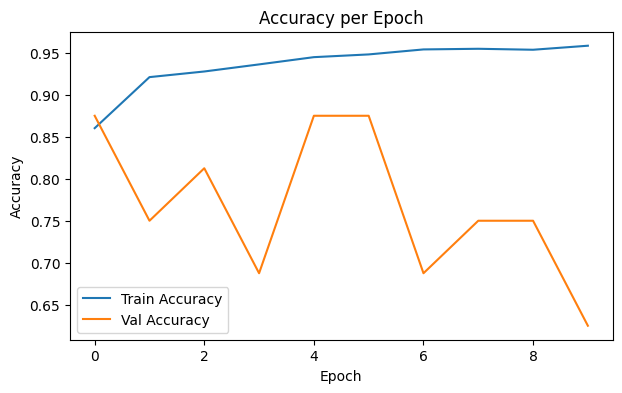

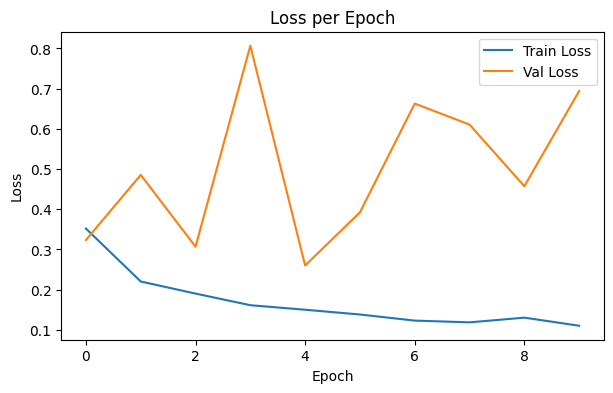

In [12]:
import matplotlib.pyplot as plt  # رسم جدول البيانات

# Accuracy جرافيك
plt.figure(figsize=(7,4))  # حجمو
plt.plot(history.history["accuracy"], label="Train Accuracy")  # تدريبو
plt.plot(history.history["val_accuracy"], label="Val Accuracy")  # تحققو
plt.title("Accuracy per Epoch")  # عنوانو
plt.xlabel("Epoch")  # محورو
plt.ylabel("Accuracy")  # محورو
plt.legend()  # مفتاحو
plt.show()  # عرضو

# Loss جرافيك
plt.figure(figsize=(7,4))  # حجمو
plt.plot(history.history["loss"], label="Train Loss")  # تدريبو
plt.plot(history.history["val_loss"], label="Val Loss")  # تحققو
plt.title("Loss per Epoch")  # عنوانو
plt.xlabel("Epoch")  # محورو
plt.ylabel("Loss")  # محورو
plt.legend()  # مفتاحو
plt.show()  # عرضو

20/20 ━━━━━━━━━━━━━━━━━━━━ 5s 230ms/step
Classification Report:

              precision    recall  f1-score   support

           0       0.96      0.59      0.73       234
           1       0.80      0.98      0.88       390

    accuracy                           0.84       624
   macro avg       0.88      0.79      0.81       624
weighted avg       0.86      0.84      0.83       624



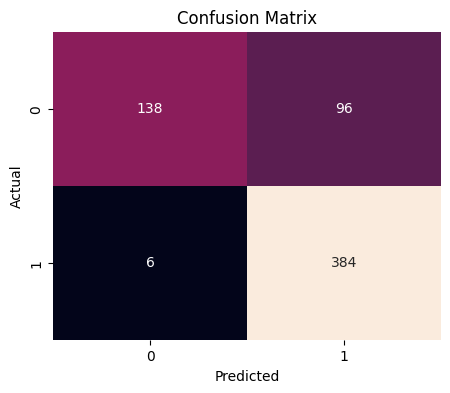

In [13]:
import numpy as np  # حساباتو
import seaborn as sns  # رسمو
from sklearn.metrics import confusion_matrix, classification_report  # تقييمو

# توقعات على test
pred_probs = model.predict(test_data)  # احتمالاتو
pred_classes = (pred_probs > 0.5).astype("int32").ravel()  # تحويلو 0/1

# confusion matrix
cm = confusion_matrix(test_data.classes, pred_classes)  # حسابو

print("Classification Report:\n")
print(classification_report(test_data.classes, pred_classes))  # تقريرو

plt.figure(figsize=(5,4))  # حجمو
sns.heatmap(cm, annot=True, fmt="d", cbar=False)  # رسمو
plt.title("Confusion Matrix")  # عنوانو
plt.xlabel("Predicted")  # محورو
plt.ylabel("Actual")  # محورو
plt.show()  # عرضو

In [14]:
model.save("chest_xray_cnn_model.h5")  # حفظ النموذج
print("Model kaydedildi: chest_xray_cnn_model.h5")  # رسالة

Model kaydedildi: chest_xray_cnn_model.h5


In [15]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [16]:
import os, shutil

SUBMIT_DIR = "/content/drive/MyDrive/ChestXRay_Submission"
os.makedirs(SUBMIT_DIR, exist_ok=True)

print("Submission folder:", SUBMIT_DIR)

Submission folder: /content/drive/MyDrive/ChestXRay_Submission


In [17]:
if os.path.exists("chest_xray_cnn_model.h5"):
    shutil.copy("chest_xray_cnn_model.h5", SUBMIT_DIR)
    print("Copied model.")
else:
    print("Model file not found, skip.")

Copied model.


In [18]:
# حساب عدد الصور في train/val/test
from pathlib import Path

def count_images(folder):
    return len([f for f in Path(folder).iterdir() if f.suffix.lower() in [".jpg",".jpeg",".png"]])

splits = ["train", "val", "test"]
classes = ["NORMAL", "PNEUMONIA"]

for sp in splits:
    print("\n==", sp.upper(), "==")
    total_sp = 0
    for cl in classes:
        c = count_images(base_dir / sp / cl)
        total_sp += c
        print(cl, ":", c)
    print("TOTAL", sp, ":", total_sp)



== TRAIN ==
NORMAL : 1341
PNEUMONIA : 3875
TOTAL train : 5216

== VAL ==
NORMAL : 8
PNEUMONIA : 8
TOTAL val : 16

== TEST ==
NORMAL : 234
PNEUMONIA : 390
TOTAL test : 624
